In [2]:
# coding = utf-8
import numpy as np
import torch
import torch.optim as optim
import pandas as pd
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import Module.PINN as PINN
import Module.DualBranchNN as DualBranchNN
import Module.AsPINN as AsPINN
import Module.OddNN as OddNN
import Module.EvenNN as EvenNN
import Module.AsPINN as AsPINN
import Module.SingleVis as SingleVis
import Module.GroupVis as GroupVis
import Module.Training_v2 as Training_v2
# import Module.Training_v2t as Training_v2t
import importlib

plt.rcParams["figure.dpi"] = 300
plt.rcParams['font.sans-serif'] = ['Times New Roman']
plt.rcParams['xtick.labelsize'] = 10    #轴标签大小
plt.rcParams['ytick.labelsize'] = 10    
plt.rcParams['axes.titlesize'] = 17     #标题字体大小
plt.rcParams['axes.labelsize'] = 16     #轴名称大小
plt.rcParams['axes.linewidth'] = 1      #轴粗细

torch.manual_seed(1234)  

if torch.cuda.is_available():
    device = torch.device('cuda')
    print("GPU is available")
else:
    device = torch.device('cpu')

GPU is available


## 调用原training类的做法

In [15]:
import Module.Training_v201 as Training

# ques_name = 'Burgers_inv_distill'
# ques_name = 'Burgers_global'
# ques_name = 'Laplace_comp'
# ques_name = 'Laplace_distill'
ques_name = 'Divfree_inv_distill'
# ques_name = 'Thermal_3d_distill'
# ques_name = 'LO_global_short10'
# ques_name = 'KdV_global'
ini_num = 2

# 在这里选择是student还是teacher
mode = 'student'
# mode = 'teacher'

seed = 1234
# model = Training_v2.model(ques_name, ini_num, seed)
model = Training.model(ques_name, ini_num, seed)

# print(model.model_ini_dict['model'])
module = importlib.import_module(f"Module.{model.model_ini_dict['model'][0]}")
# module = importlib.import_module(f"{model.model_ini_dict['model']}")
NetClass = getattr(module, 'Net')

model_desti = model.save_desti + '/Models/'
model_list =  os.listdir(model_desti)  

# 如果是PINN模型就得传入layer参数
if 'PINN' == model.model_ini_dict['model']:
    model.net = NetClass(model.layer).float().to(device)
else:
    model.net = NetClass(model.node_num).float().to(device)

model_filename = f"{model.ques_name}_{model.ini_num}_{model.net.__module__.split('.')[-1]}.pth"

model.net.load_state_dict(torch.load(model_desti + model_filename))

if model.distill_state:

    model.net_student = PINN.Net(model.layer_student).float().to(device)

    model_filename_student = f"{model.ques_name}_{model.ini_num}_{model.net_student.__module__.split('.')[-1]}_student.pth"
    # model_filename_student = f"{model.ques_name}_{model.ini_num}_{model.net_student.__module__.split('.')[-1]}_student_step_100000.pth"

    model.net_student.load_state_dict(torch.load(model_desti + model_filename_student))

if mode == 'student':
    net = model.net_student
elif mode == 'teacher':
    net = model.net

Distill state: True


RuntimeError: Error(s) in loading state_dict for Net:
	Missing key(s) in state_dict: "fc1.weight", "fc1.bias", "fc2.weight", "fc2.bias". 
	Unexpected key(s) in state_dict: "fc1_1.weight", "fc1_1.bias", "fc1_2.weight", "fc1_2.bias", "fc2_1.weight", "fc2_1.bias", "fc2_2.weight", "fc2_2.bias". 

In [19]:
# 绘制图像
model.figure_node_num = 50
x = np.linspace(model.x_min, model.x_max, model.figure_node_num).reshape([-1,1])
y = np.linspace(model.y_min, model.y_max, model.figure_node_num).reshape([-1,1])
z = np.linspace(model.z_min, model.z_max, model.figure_node_num).reshape([-1,1])
x, y, z = np.meshgrid(x, y, z)
x = torch.tensor(x).float().to(device).reshape([-1,1])
y = torch.tensor(y).float().to(device).reshape([-1,1])
z = torch.tensor(z).float().to(device).reshape([-1,1])

u = model.net(torch.cat([x, y, z], dim=1))
if model.distill_state:
    u_student = model.net_student(torch.cat([x, y, z], dim=1))
    u_student = u_student.detach().cpu().numpy()
x = x.detach().cpu().numpy()
y = y.detach().cpu().numpy()
z = z.detach().cpu().numpy()
u = u.detach().cpu().numpy()
u_vis = SingleVis.Vis(model.ques_name, model.ini_num, model.save_desti, model.net.__module__.split('.')[-1], x, y, z, u)
u_vis.figure_3d()
# u_vis.loss_vis()

if model.distill_state:
    u_student_vis = SingleVis.Vis(model.ques_name, model.ini_num, model.save_desti, model.net_student.__module__.split('.')[-1], x, y, z, u_student, mode='student')
    u_student_vis.figure_3d()
    u_student_vis.loss_vis()


In [4]:
# 给出所有的参数
for name, param in net.named_parameters():
    if param.requires_grad:
        print(name, '\n', param.data)

layers.layer_0.weight 
 tensor([[ 9.8463e-09,  3.9107e-08],
        [-3.5933e-01, -6.2255e-01],
        [ 3.5933e-01,  6.2255e-01],
        [-3.5944e-01,  6.2247e-01],
        [ 6.6729e-01, -1.6017e-04],
        [-6.6492e-01,  1.5449e-04],
        [-6.6725e-01,  1.6005e-04],
        [ 3.5944e-01, -6.2247e-01]], device='cuda:0')
layers.layer_0.bias 
 tensor([-1.3824e-05, -2.1692e-07,  2.1691e-07, -1.1958e-07, -1.0797e-06,
         1.0747e-06,  1.0796e-06,  1.1957e-07], device='cuda:0')
layers.layer_1.weight 
 tensor([[-3.0134e-06,  4.2748e-01, -4.2748e-01,  4.2766e-01,  3.0001e-01,
         -2.9820e-01, -2.9997e-01, -4.2766e-01],
        [-3.0472e-06,  4.3670e-01, -4.3670e-01,  4.3687e-01,  3.0506e-01,
         -3.0320e-01, -3.0503e-01, -4.3687e-01],
        [-2.5199e-06,  3.1855e-01, -3.1855e-01,  3.1866e-01,  2.4190e-01,
         -2.4066e-01, -2.4187e-01, -3.1866e-01],
        [-2.8404e-06,  3.8395e-01, -3.8395e-01,  3.8410e-01,  2.7641e-01,
         -2.7485e-01, -2.7638e-01, -3.8410e

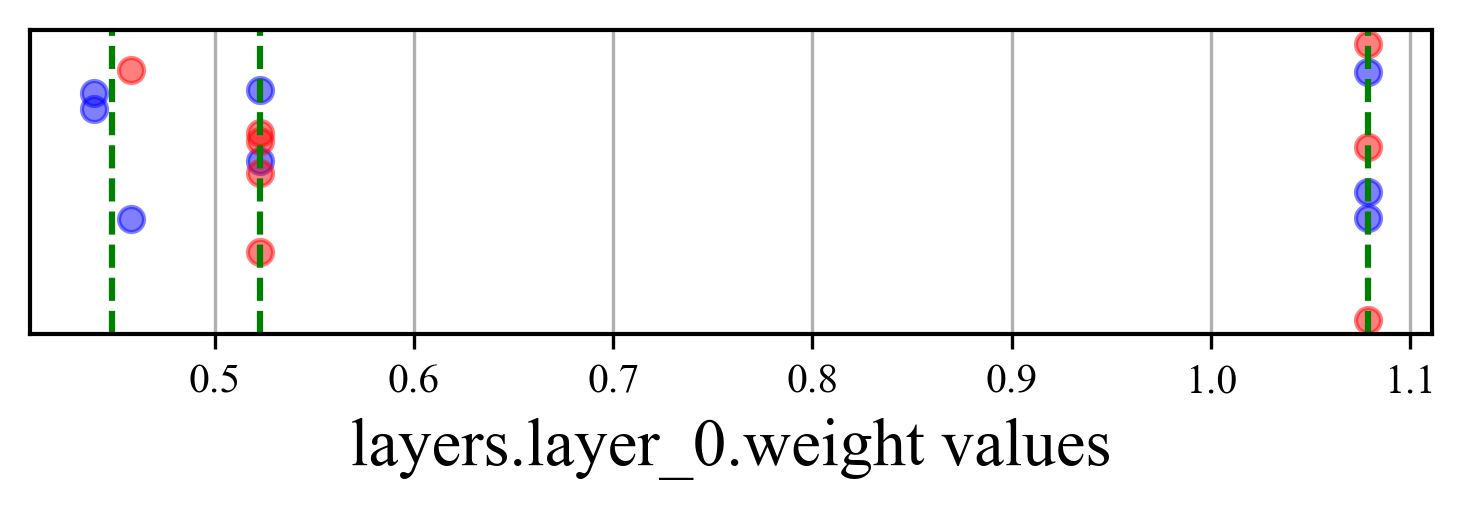

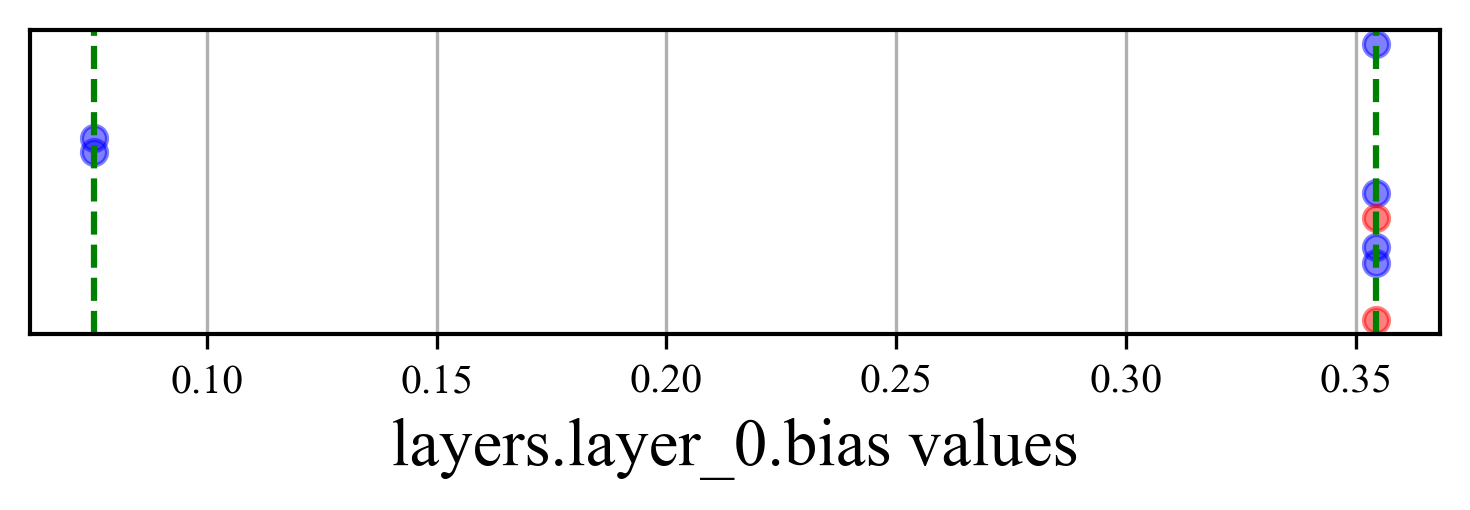

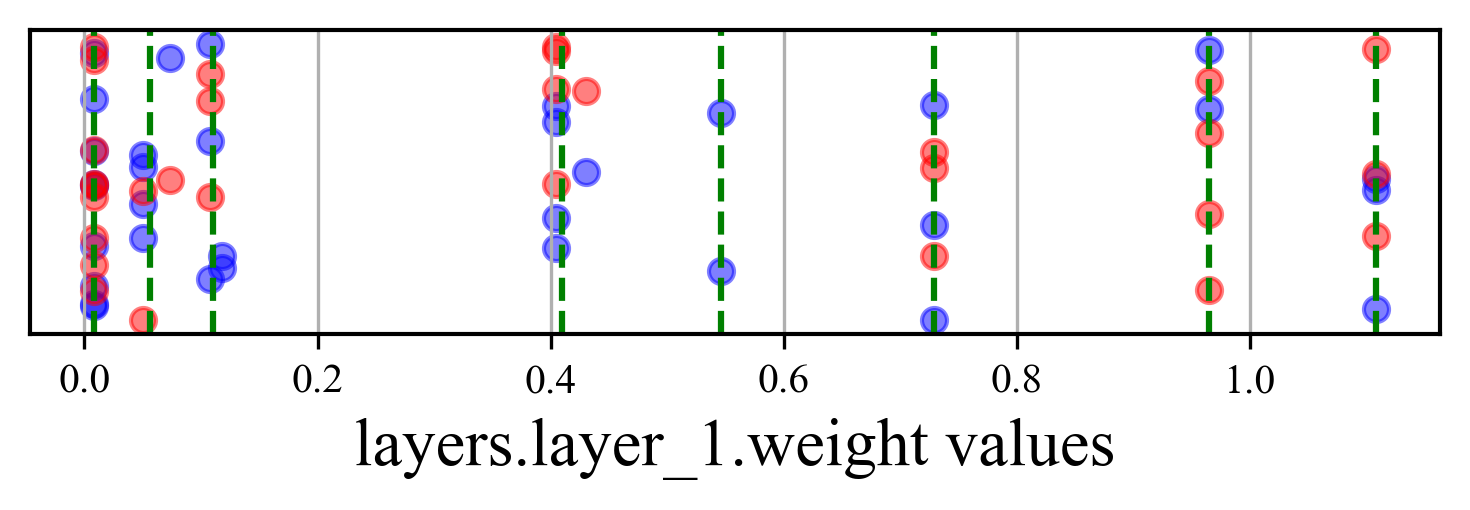

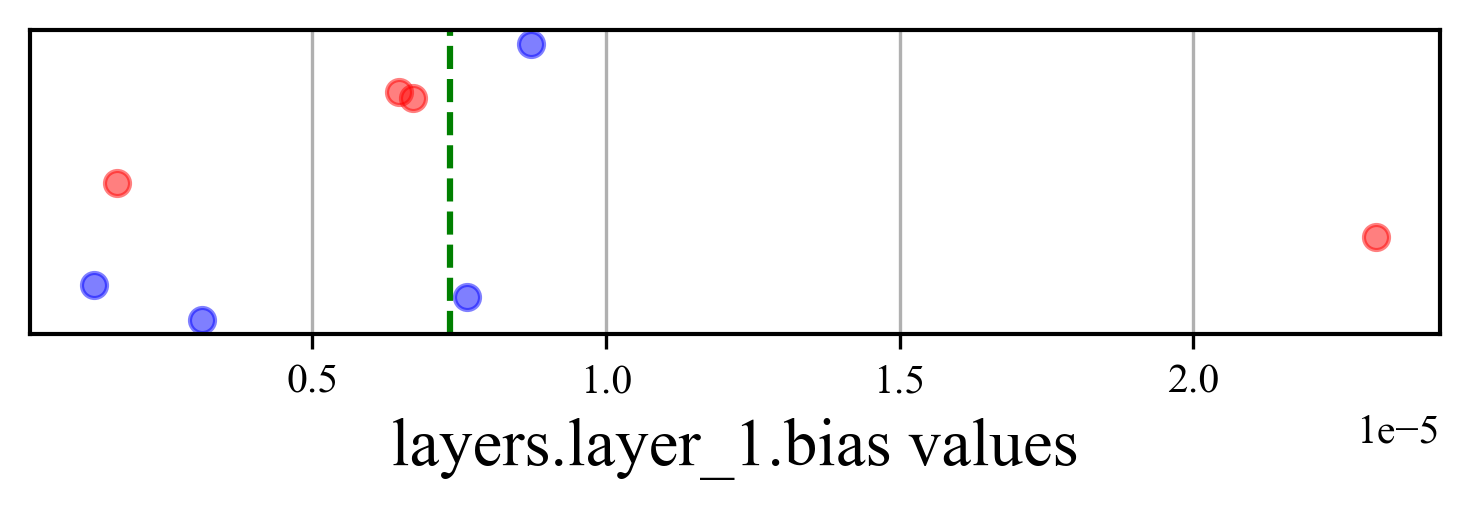

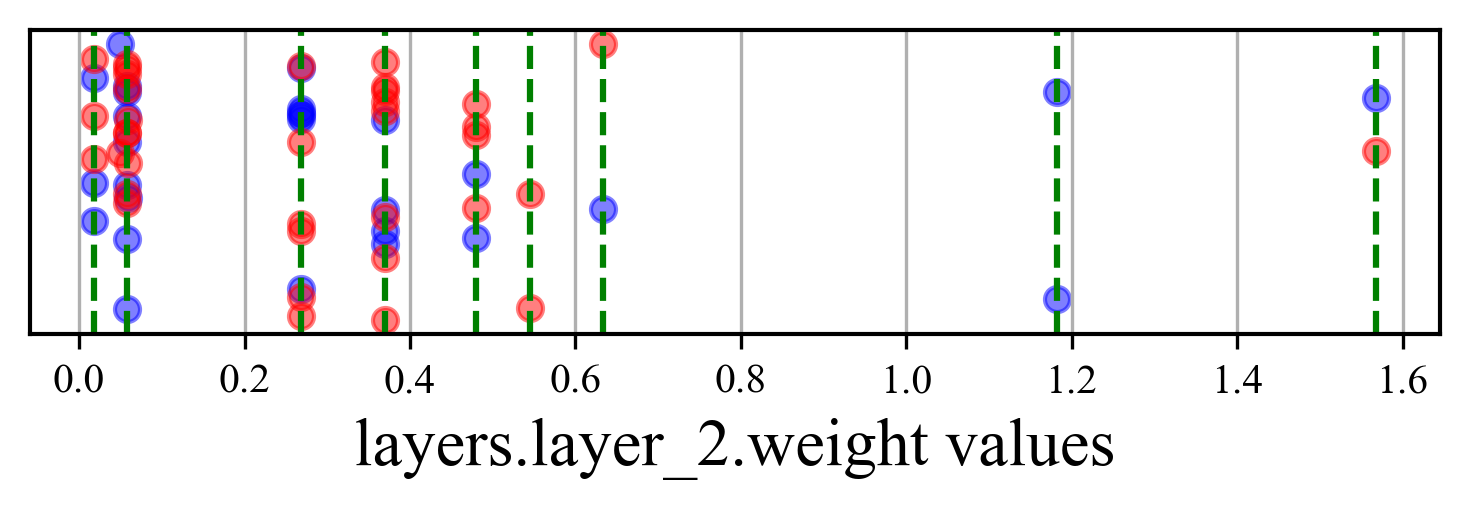

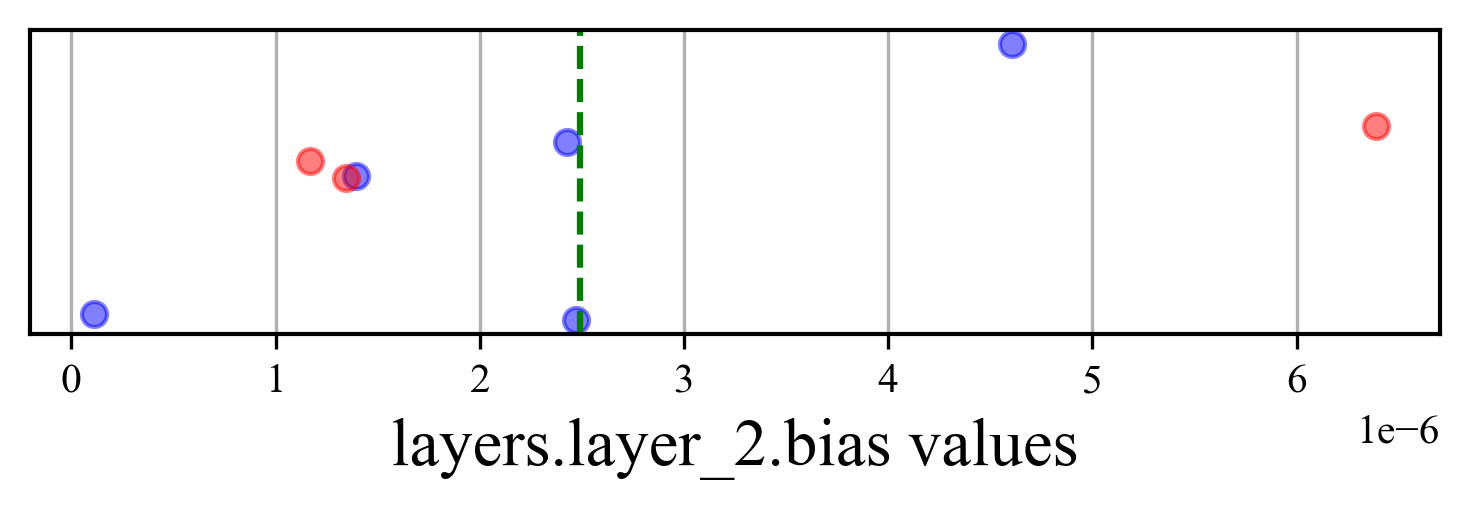

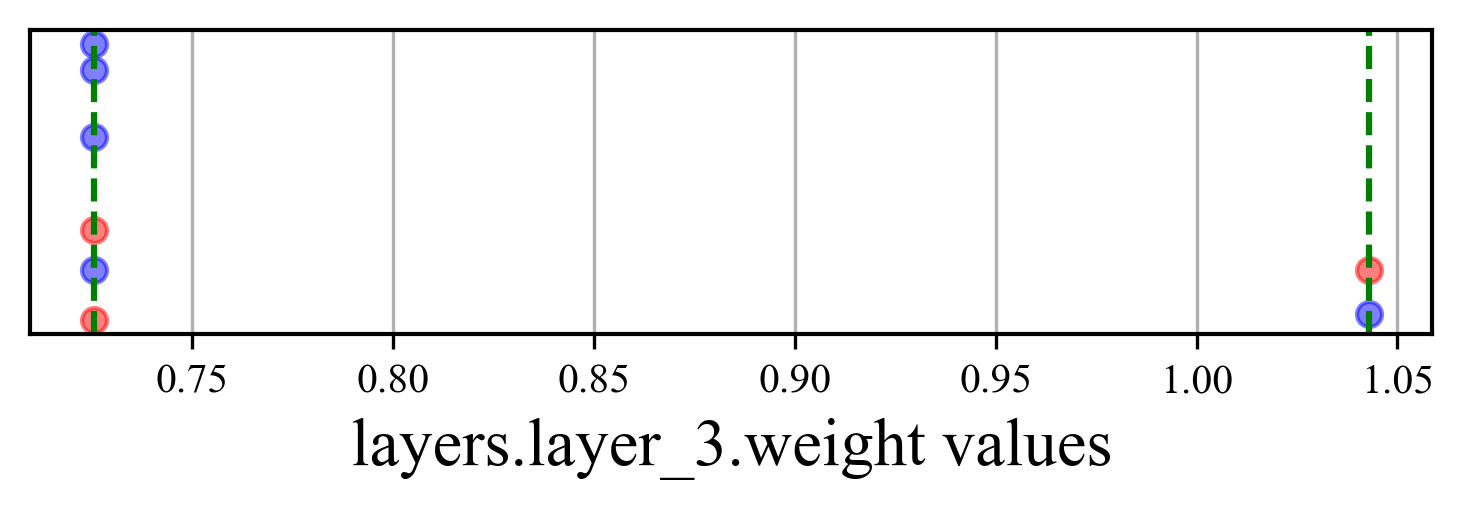

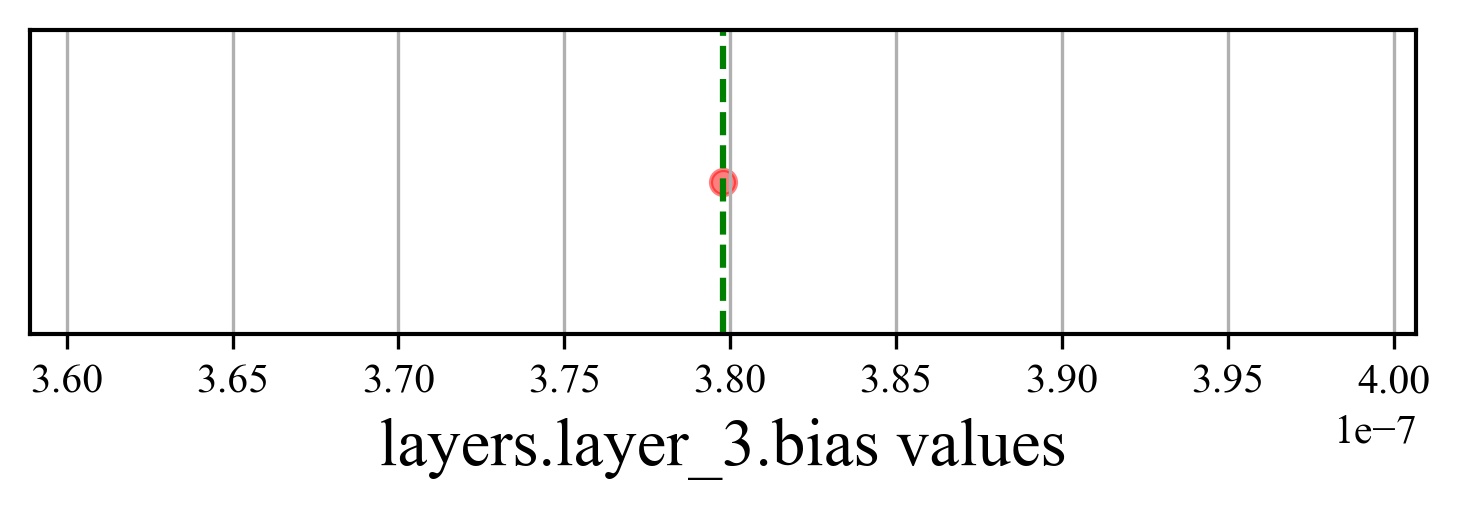

In [16]:
# 有聚类的分类，并且无论结构
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

for name, param in net.named_parameters():

    # # 提取该层的权重
    # layer_weights = list(net.parameters())[layer_index].detach().cpu().numpy().flatten()
    # if layer_index % 2 == 0:
    #     name = 'Weights'
    # else:
    #     name = 'Biases'
    layer_weights = param.detach().cpu().numpy().flatten()

    # 将所有的负值转化为正值，并标识为红色
    positive_weights = layer_weights[layer_weights >= 0]
    negative_weights = -layer_weights[layer_weights < 0]  # 转化为正值

    # 为了更好地辨别，将点沿着y轴方向稍微分开
    y_positive = np.random.uniform(-0.1, 0.1, size=len(positive_weights))
    y_negative = np.random.uniform(-0.1, 0.1, size=len(negative_weights))


    # 计算权重的绝对值
    abs_weights = np.abs(layer_weights).reshape(-1, 1)

    # 检查权重数量是否少于两个
    if len(abs_weights) < 2:
        cluster_centers = [abs_weights.mean()]
    else:
        # 使用层次聚类对权重进行分类
        Z = linkage(abs_weights, method='ward')
        max_distance = 0.1  # 设置最大距离阈值
        labels = fcluster(Z, max_distance, criterion='distance')

        # 计算每个聚类的中心
        cluster_centers = []
        for label in np.unique(labels):
            cluster_center = abs_weights[labels == label].mean()
            cluster_centers.append(cluster_center)

    # 绘制权重在一维数轴上的分布
    plt.figure(figsize=(5, 1.8))
    # plt.figure()

    # 绘制正值权重
    plt.scatter(positive_weights, y_positive, color='blue', alpha=0.5, label=f'Positive {name}')

    # 绘制负值权重（已转化为正值）
    plt.scatter(negative_weights, y_negative, color='red', alpha=0.5, label=f'Negative {name} (converted to positive)')
    
    # 绘制聚类中心
    for i, center in enumerate(cluster_centers):
        plt.axvline(x=center, color='green', linestyle='--', label='Cluster Center' if i == 0 else "")

    plt.yticks([])
    plt.xlabel(f'{name} values')
    # plt.title(f'{name} distribution')
    plt.grid()
    # plt.legend()    
    # plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))  # 将图例移到图像右侧

    # 调整图像布局以避免标题被截掉
    plt.tight_layout()  

    if os.path.exists(f'./Figures/{ques_name}_{ini_num}/Weights_vis') == False:
        os.makedirs(f'./Figures/{ques_name}_{ini_num}/Weights_vis')
    plt.savefig(f'./Figures/{ques_name}_{ini_num}/Weights_vis/{ques_name}_{ini_num}_{name}_distribution.png')
    plt.show()

    
    plt.close()

In [6]:
# 结构识别
import string
from scipy.cluster.hierarchy import linkage, fcluster
for name, param in net.named_parameters():
    # 提取该层的权重
    layer_weights = param.detach().cpu().numpy()
    flattened_weights = layer_weights.flatten()

    # 计算权重的绝对值
    abs_weights = np.abs(flattened_weights).reshape(-1, 1)

    # 检查权重数量是否少于两个
    if len(abs_weights) < 2:
        cluster_centers = [abs_weights.mean()]
        labels = np.zeros_like(flattened_weights, dtype=int)
    else:
        # 使用层次聚类对权重进行分类
        Z = linkage(abs_weights, method='ward')
        max_distance = 0.1  # 设置最大距离阈值
        labels = fcluster(Z, max_distance, criterion='distance')

        # 计算每个聚类的中心
        cluster_centers = []
        for label in np.unique(labels):
            cluster_center = abs_weights[labels == label].mean()
            cluster_centers.append(cluster_center)

    # 检查 cluster_centers 是否为空
    if len(cluster_centers) == 0:
        print(f"Layer {name} has no valid clusters.")
        continue

    # 使用字母代号标识聚类中心
    cluster_labels = {i + 1: letter for i, letter in enumerate(string.ascii_uppercase[:len(cluster_centers)])}
    cluster_mapping = {letter: center for letter, center in zip(cluster_labels.values(), cluster_centers)}

    # 替换权重为聚类中心，同时保留原始符号
    clustered_weights = np.array([
        cluster_centers[label - 1] * np.sign(weight) if label - 1 < len(cluster_centers) else 0
        for label, weight in zip(labels, flattened_weights)
    ])
    clustered_weights = clustered_weights.reshape(layer_weights.shape)

    # 生成符号化的字母代号矩阵
    symbolized_weights = np.array([
        f"{'-' if weight < 0 else ''}{cluster_labels[label]}"
        if label in cluster_labels else "0"
        for weight, label in zip(flattened_weights, labels)
    ])
    symbolized_weights = symbolized_weights.reshape(layer_weights.shape)

    # 将替换后的权重分层输出为字母代号矩阵形式
    print(f"Layer: {name}")
    print("Symbolized Weights Matrix:")
    print(symbolized_weights)

    # 输出聚类中心的字母代号映射
    print("Cluster Mapping (Letter -> Center):")
    for letter, center in cluster_mapping.items():
        print(f"{letter}: {center}")

    # 如果需要将替换后的权重保存回模型中
    # param.data = torch.tensor(clustered_weights, dtype=param.data.dtype, device=param.data.device)

Layer: layers.layer_0.weight
Symbolized Weights Matrix:
[['A' 'A']
 ['-B' '-C']
 ['B' 'C']
 ['-B' 'C']
 ['C' '-A']
 ['-C' 'A']
 ['-C' 'A']
 ['B' '-C']]
Cluster Mapping (Letter -> Center):
A: 9.495163976680487e-05
B: 0.35938775539398193
C: 0.6413573026657104
Layer: layers.layer_0.bias
Symbolized Weights Matrix:
['-A' '-A' 'A' '-A' '-A' 'A' 'A' 'A']
Cluster Mapping (Letter -> Center):
A: 2.216411303379573e-06
Layer: layers.layer_1.weight
Symbolized Weights Matrix:
[['-A' 'E' '-E' 'E' 'B' '-B' '-B' '-E']
 ['-A' 'E' '-E' 'E' 'B' '-B' '-B' '-E']
 ['-A' 'B' '-B' 'B' 'C' '-C' '-C' '-B']
 ['-A' 'D' '-D' 'D' 'C' '-C' '-C' '-D']
 ['A' '-E' 'E' '-E' '-B' 'B' 'B' 'E']
 ['A' '-D' 'D' '-D' '-C' 'C' 'C' 'D']
 ['A' '-E' 'E' '-E' '-B' 'B' 'B' 'E']
 ['A' '-E' 'E' '-E' '-B' 'B' 'B' 'E']]
Cluster Mapping (Letter -> Center):
A: 2.8834074328187853e-06
B: 0.30033087730407715
C: 0.2620258033275604
D: 0.37731850147247314
E: 0.42030006647109985
Layer: layers.layer_1.bias
Symbolized Weights Matrix:
['A' 'A' '-A'

## 随意加载一个pth文件并聚类
这样似乎更好一点，因为可以随意弄

odict_keys(['layers.layer_0.weight', 'layers.layer_0.bias', 'layers.layer_1.weight', 'layers.layer_1.bias', 'layers.layer_2.weight', 'layers.layer_2.bias', 'layers.layer_3.weight', 'layers.layer_3.bias'])


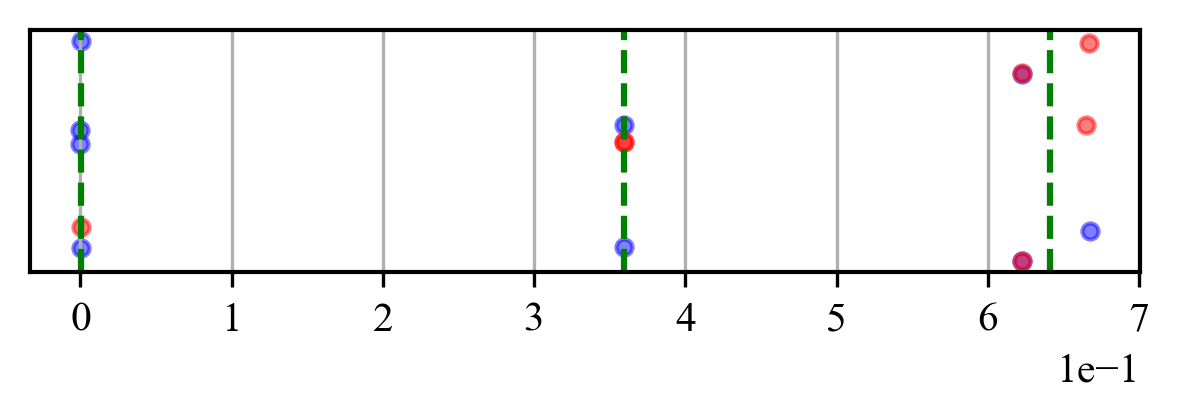

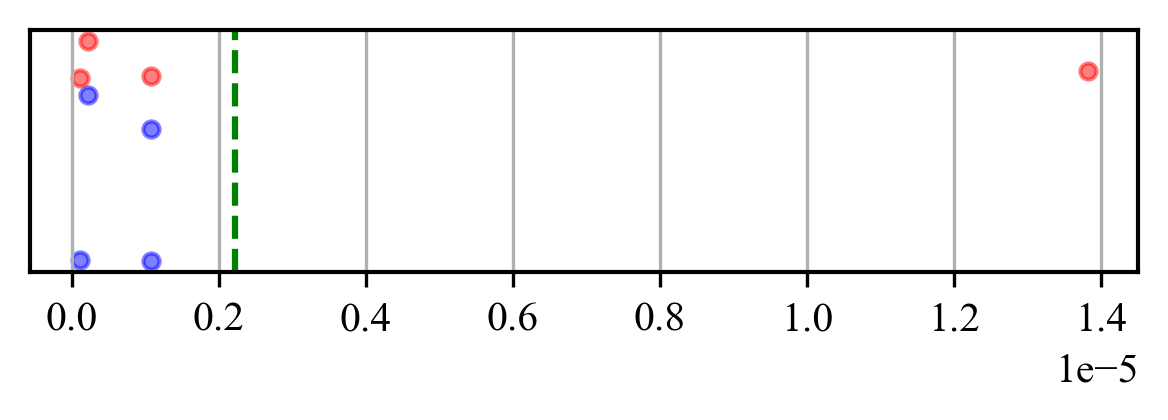

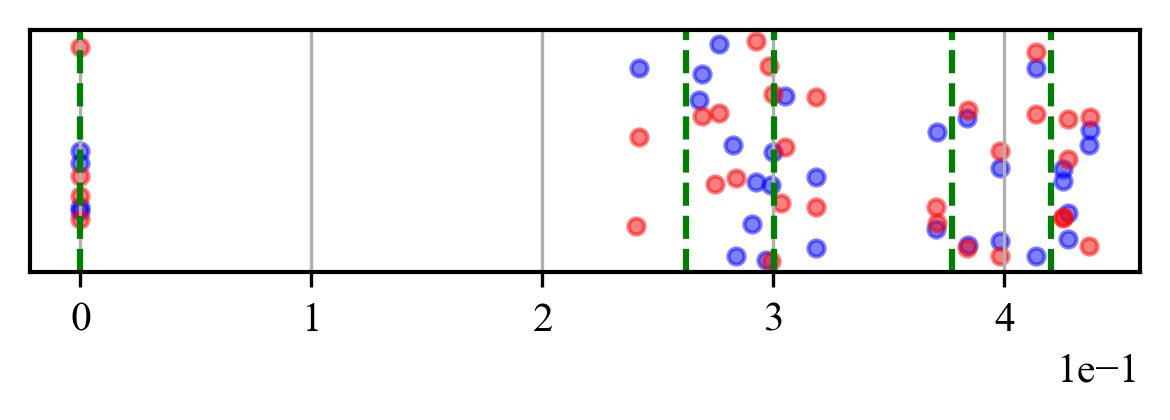

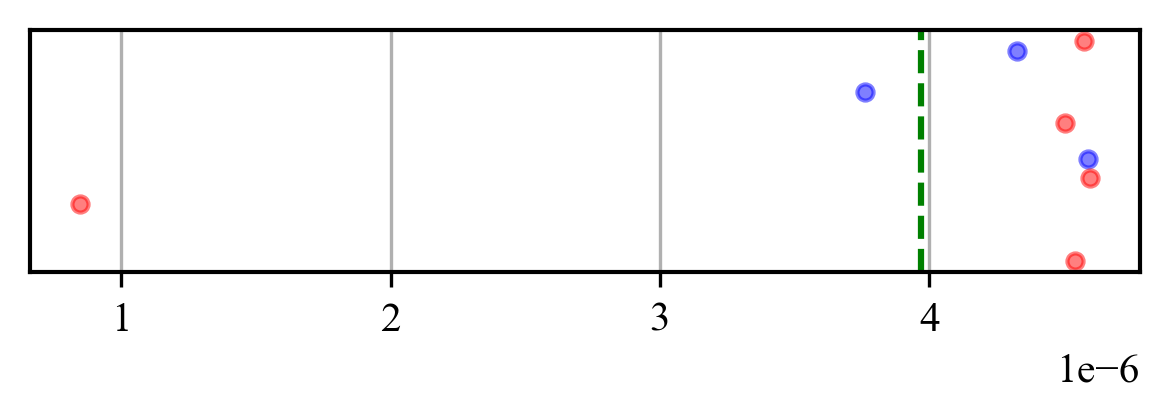

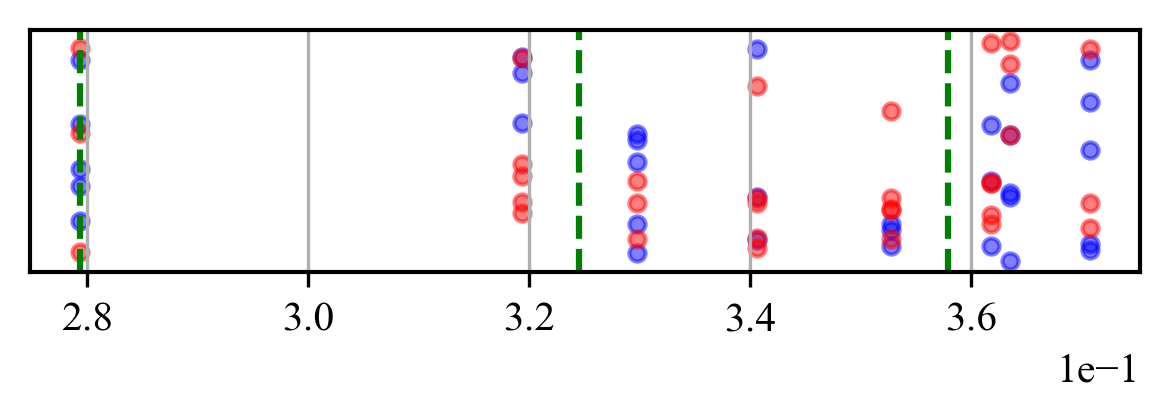

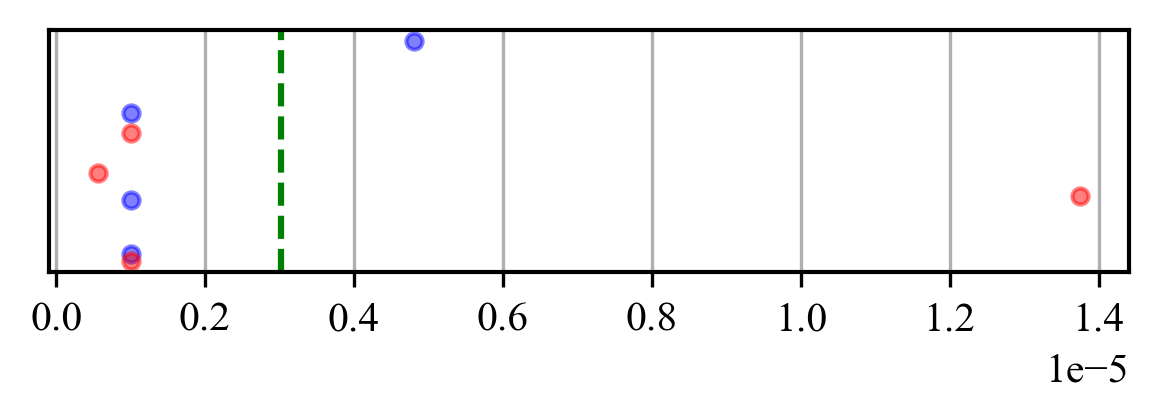

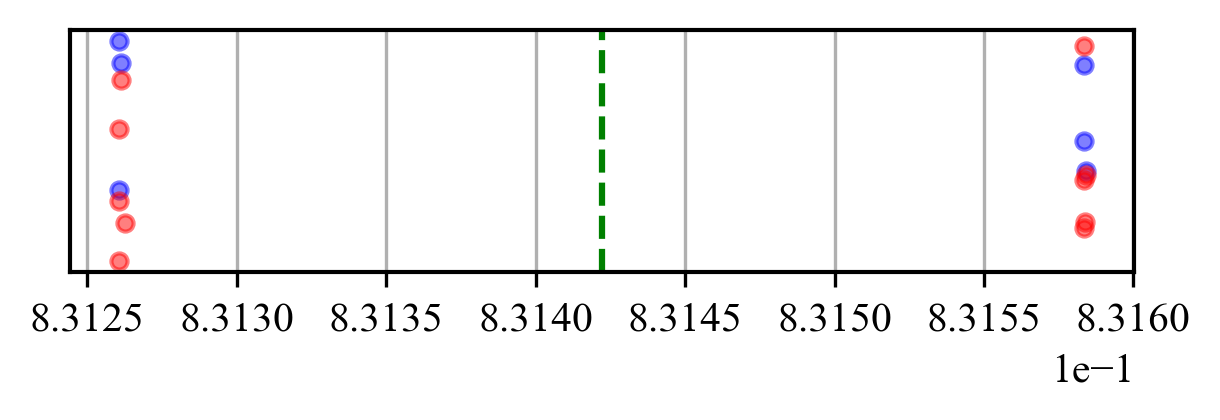

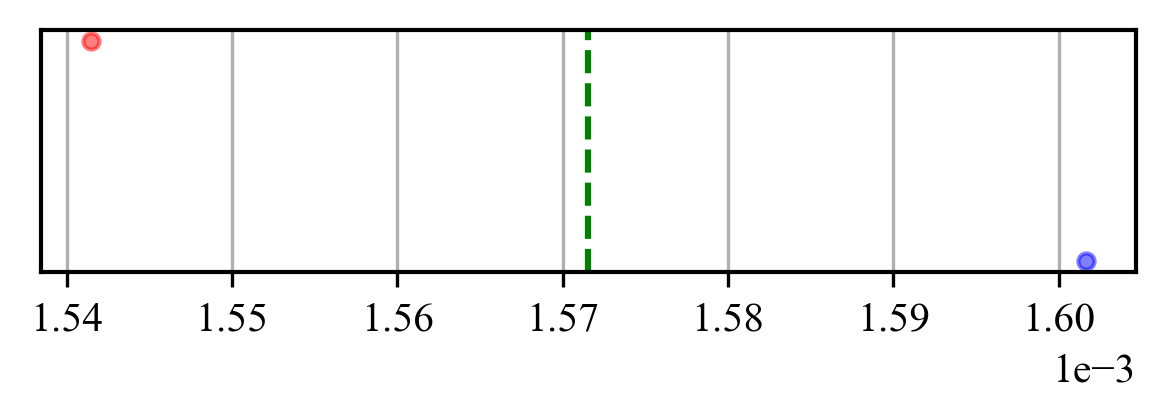

In [12]:
# 加载其他的.pth 文件并聚类绘图

# 有聚类的分类，并且无论结构
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist

# ques_name = 'Poisson_global_lf'
# ques_name = 'LO_global_short11'
# ques_name = 'Burgers_inv_comp'
# ques_name = 'Burgers_global'
ques_name = 'Laplace_distill'
ini_num = 1
# model_name = 'DualBranchNN_DO'
model_name = 'PINN'

# ques_name = 'Divfree_inv_distill'
# ini_num = 1.0
# model_name = 'PINN_post_divfree'

mode = 'student'

if mode == 'student':
    model_name += '_student'

file_path = f"./Results/{ques_name}_{ini_num}_seed(1234)/Models/{ques_name}_{ini_num}_{model_name}_step_100000.pth"
# file_path = f"./Results/{ques_name}_{ini_num}/Models/{ques_name}_{ini_num}_{model_name}_step_100000.pth"  # 替换为你的文件路径
named_params = torch.load(file_path)
print(named_params.keys())

for name, param in named_params.items():

    # # 提取该层的权重
    # layer_weights = list(net.parameters())[layer_index].detach().cpu().numpy().flatten()
    # if layer_index % 2 == 0:
    #     name = 'Weights'
    # else:
    #     name = 'Biases'
    layer_weights = param.detach().cpu().numpy().flatten()

    # 将所有的负值转化为正值，并标识为红色
    positive_weights = layer_weights[layer_weights >= 0]
    negative_weights = -layer_weights[layer_weights < 0]  # 转化为正值

    # 为了更好地辨别，将点沿着y轴方向稍微分开
    y_positive = np.random.uniform(-0.1, 0.1, size=len(positive_weights))
    y_negative = np.random.uniform(-0.1, 0.1, size=len(negative_weights))


    # 计算权重的绝对值
    abs_weights = np.abs(layer_weights).reshape(-1, 1)

    # 检查权重数量是否少于两个
    if len(abs_weights) < 2:
        cluster_centers = [abs_weights.mean()]
    else:
        # 使用层次聚类对权重进行分类
        Z = linkage(abs_weights, method='ward')
        max_distance = 0.1  # 设置最大距离阈值
        labels = fcluster(Z, max_distance, criterion='distance')

        # 计算每个聚类的中心
        cluster_centers = []
        for label in np.unique(labels):
            cluster_center = abs_weights[labels == label].mean()
            cluster_centers.append(cluster_center)

    # 绘制权重在一维数轴上的分布
    plt.figure(figsize=(4, 1.5))
    # plt.figure()

    # 绘制正值权重
    dot_size = 15

    plt.scatter(positive_weights, y_positive, color='blue', alpha=0.5, s=dot_size, label=f'Positive {name}')

    # 绘制负值权重（已转化为正值）
    plt.scatter(negative_weights, y_negative, color='red', alpha=0.5, s=dot_size, label=f'Negative {name} (converted to positive)')
    
    # 绘制聚类中心
    for i, center in enumerate(cluster_centers):
        plt.axvline(x=center, color='green', linestyle='--', label='Cluster Center' if i == 0 else "")

    plt.yticks([])
    # 取消x轴坐标
    # plt.xticks([])
    # x坐标变为科学计数法
    plt.ticklabel_format(style='sci', axis='x', scilimits=(0, 0))

    # plt.xlabel(f'{name} values')
    # plt.title(f'{name} distribution')
    plt.grid()
    # plt.legend()

    # 调整图像布局以避免标题被截掉
    plt.tight_layout()  

    if os.path.exists(f'./Figures/{ques_name}_{ini_num}/Weights_vis') == False:
        os.makedirs(f'./Figures/{ques_name}_{ini_num}/Weights_vis')
    plt.savefig(f'./Figures/{ques_name}_{ini_num}/Weights_vis/{ques_name}_{ini_num}_{name}_distribution.png')
    plt.show()

    
    plt.close()

In [5]:
# 给出所有的参数
for name, param in named_params.items():
    print(name, '\n', param.data)

fc1.weight 
 tensor([[-0.6394,  0.0548],
        [-0.6394,  0.0548],
        [-0.6298,  0.6367],
        [-0.2215,  0.1633],
        [ 0.0850, -0.6738],
        [ 0.8823,  0.8748],
        [-0.0837,  0.6755],
        [-0.6295,  0.6355]], device='cuda:0')
fc1.bias 
 tensor([ 4.2951e-05,  4.3031e-05, -1.0606e+00,  9.1959e-04, -2.5185e-01,
         1.6353e-04, -2.4857e-01,  1.0596e+00], device='cuda:0')
fc2.weight 
 tensor([[-0.2445, -0.2445, -0.0390, -0.0160, -0.2467, -0.8409,  0.2356,  0.0267],
        [-0.3061, -0.3061,  0.8248, -0.2316,  0.6704,  0.0398,  0.0490, -1.9413],
        [-0.2617, -0.2617,  0.0081, -0.0178, -0.2545, -0.8552,  0.2625, -0.0208],
        [ 0.3062,  0.3062,  1.9435,  0.2297,  0.0529, -0.0396,  0.6670, -0.8230],
        [-0.3307, -0.3306, -0.2688, -0.2268,  0.3464, -0.0072, -0.3462, -0.2674],
        [-0.5215, -0.5215, -0.3544, -0.1680, -0.1089,  0.5640,  0.1099, -0.3544],
        [-0.2530, -0.2530,  0.0117, -0.0169, -0.2450, -0.8461,  0.2544, -0.0241],
        [

In [11]:
# 结构识别
import string
from scipy.cluster.hierarchy import linkage, fcluster
for name, param in named_params.items():
    # 提取该层的权重
    layer_weights = param.detach().cpu().numpy()
    flattened_weights = layer_weights.flatten()

    # 计算权重的绝对值
    abs_weights = np.abs(flattened_weights).reshape(-1, 1)

    # 检查权重数量是否少于两个
    if len(abs_weights) < 2:
        cluster_centers = [abs_weights.mean()]
        labels = np.zeros_like(flattened_weights, dtype=int)
    else:
        # 使用层次聚类对权重进行分类
        Z = linkage(abs_weights, method='ward')
        max_distance = 0.1  # 设置最大距离阈值
        labels = fcluster(Z, max_distance, criterion='distance')

        # 计算每个聚类的中心
        cluster_centers = []
        for label in np.unique(labels):
            cluster_center = abs_weights[labels == label].mean()
            cluster_centers.append(cluster_center)

    # 检查 cluster_centers 是否为空
    if len(cluster_centers) == 0:
        print(f"Layer {name} has no valid clusters.")
        continue

    # 使用字母代号标识聚类中心
    cluster_labels = {i + 1: letter for i, letter in enumerate(string.ascii_uppercase[:len(cluster_centers)])}
    cluster_mapping = {letter: center for letter, center in zip(cluster_labels.values(), cluster_centers)}

    # 替换权重为聚类中心，同时保留原始符号
    clustered_weights = np.array([
        cluster_centers[label - 1] * np.sign(weight) if label - 1 < len(cluster_centers) else 0
        for label, weight in zip(labels, flattened_weights)
    ])
    clustered_weights = clustered_weights.reshape(layer_weights.shape)

    # 生成符号化的字母代号矩阵
    symbolized_weights = np.array([
        f"{'-' if weight < 0 else ''}{cluster_labels[label]}"
        if label in cluster_labels else "0"
        for weight, label in zip(flattened_weights, labels)
    ])
    symbolized_weights = symbolized_weights.reshape(layer_weights.shape)

    # 将替换后的权重分层输出为字母代号矩阵形式
    print(f"Layer: {name}")
    print("Symbolized Weights Matrix:")
    print(symbolized_weights)

    # 输出聚类中心的字母代号映射
    print("Cluster Mapping (Letter -> Center):")
    for letter, center in cluster_mapping.items():
        print(f"{letter}: {center}")

    # 如果需要将替换后的权重保存回模型中
    # param.data = torch.tensor(clustered_weights, dtype=param.data.dtype, device=param.data.device)

Layer: fc1.weight
Symbolized Weights Matrix:
[['-A' 'B']
 ['-A' 'B']
 ['-A' 'B']
 ['-A' 'B']
 ['-B' '-A']
 ['A' '-B']
 ['B' 'A']
 ['B' 'A']
 ['-B' 'A']
 ['-B' 'A']
 ['-B' '-A']
 ['B' 'A']
 ['A' '-B']
 ['-A' '-B']
 ['-B' '-A']
 ['-B' '-A']]
Cluster Mapping (Letter -> Center):
A: 1.225144624710083
B: 0.043349750339984894
Layer: fc1.bias
Symbolized Weights Matrix:
['A' 'A' 'A' 'A' 'A' '-A' '-A' '-A' '-A' '-A' 'A' '-A' '-A' 'A' 'A' 'A']
Cluster Mapping (Letter -> Center):
A: 0.012397093698382378
Layer: fc2.weight
Symbolized Weights Matrix:
[['F' 'F' 'F' 'F' '-H' '-F' 'H' 'H' 'H' 'H' '-H' 'H' '-F' 'F' '-H' '-H']
 ['G' 'G' 'G' 'G' 'I' '-G' '-I' '-I' 'I' 'I' 'I' '-I' '-G' 'G' 'I' '-I']
 ['K' 'K' 'K' 'K' 'H' '-K' '-H' '-H' '-H' '-H' 'H' '-H' '-K' 'K' 'H' 'H']
 ['-K' '-K' '-K' '-K' '-H' 'K' 'H' 'H' 'H' 'H' '-H' 'H' 'K' '-K' '-H'
  '-H']
 ['H' 'H' 'H' 'H' 'J' '-H' '-J' '-J' '-J' '-J' 'J' '-J' '-H' 'H' 'J' 'J']
 ['A' 'A' 'A' 'A' 'F' '-A' '-F' '-F' '-E' '-E' 'F' '-F' '-A' 'A' 'F' 'F']
 ['-K' '-K' 

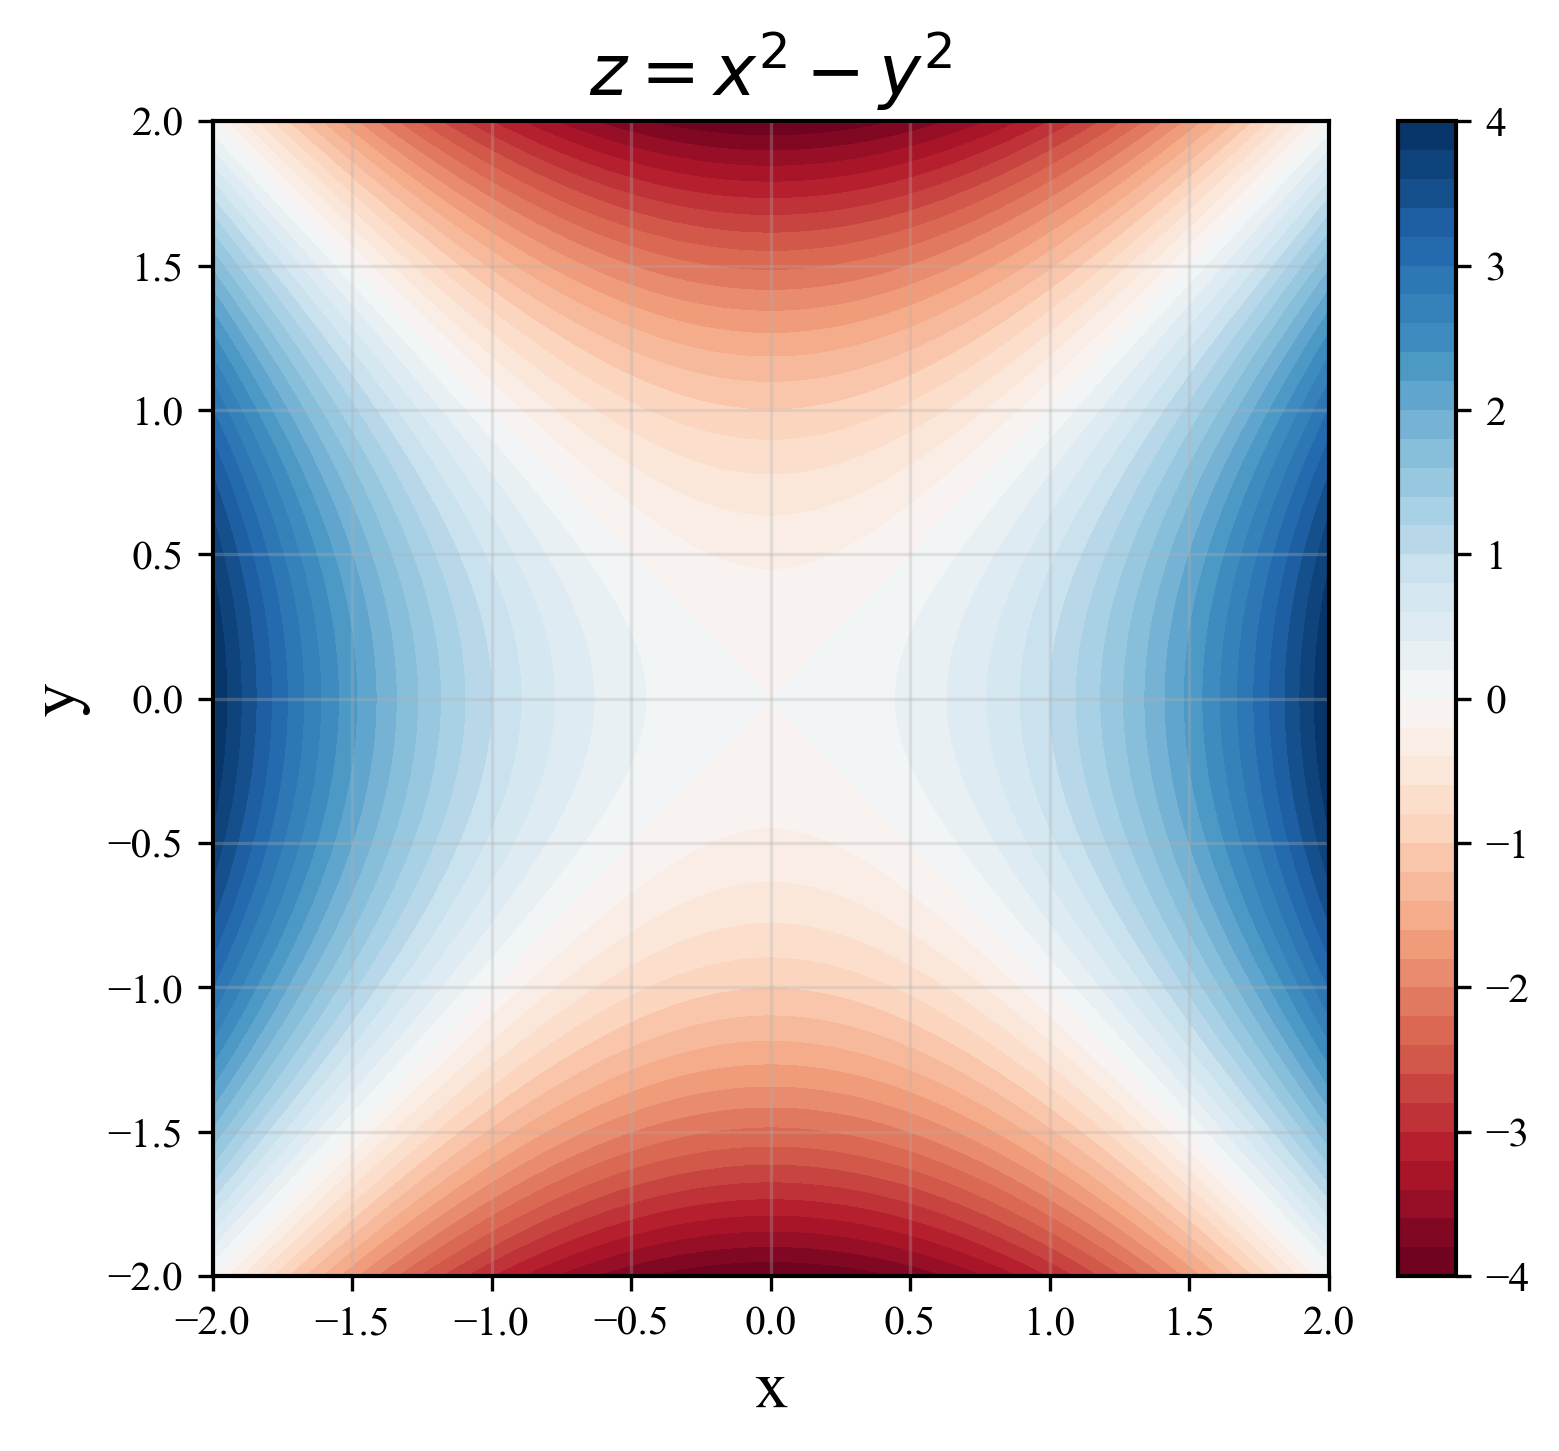

In [15]:
# 绘制x^2-y^2图像

import numpy as np
import matplotlib.pyplot as plt

# 定义 x 和 y 的范围
x = np.linspace(-2, 2, 100)  # x 的范围
y = np.linspace(-2, 2, 100)  # y 的范围

# 创建网格
X, Y = np.meshgrid(x, y)

# 计算 z = x^2 - y^2
Z = X**2 - Y**2

# 绘制二维等高线图
plt.figure(figsize=(6, 5))
contour = plt.contourf(X, Y, Z, levels=50, cmap='RdBu')  # 填充等高线
plt.colorbar(contour)  # 添加颜色条
plt.title(r"$z = x^2 - y^2$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()


[1 2 3 4]
-0.13977061618845082


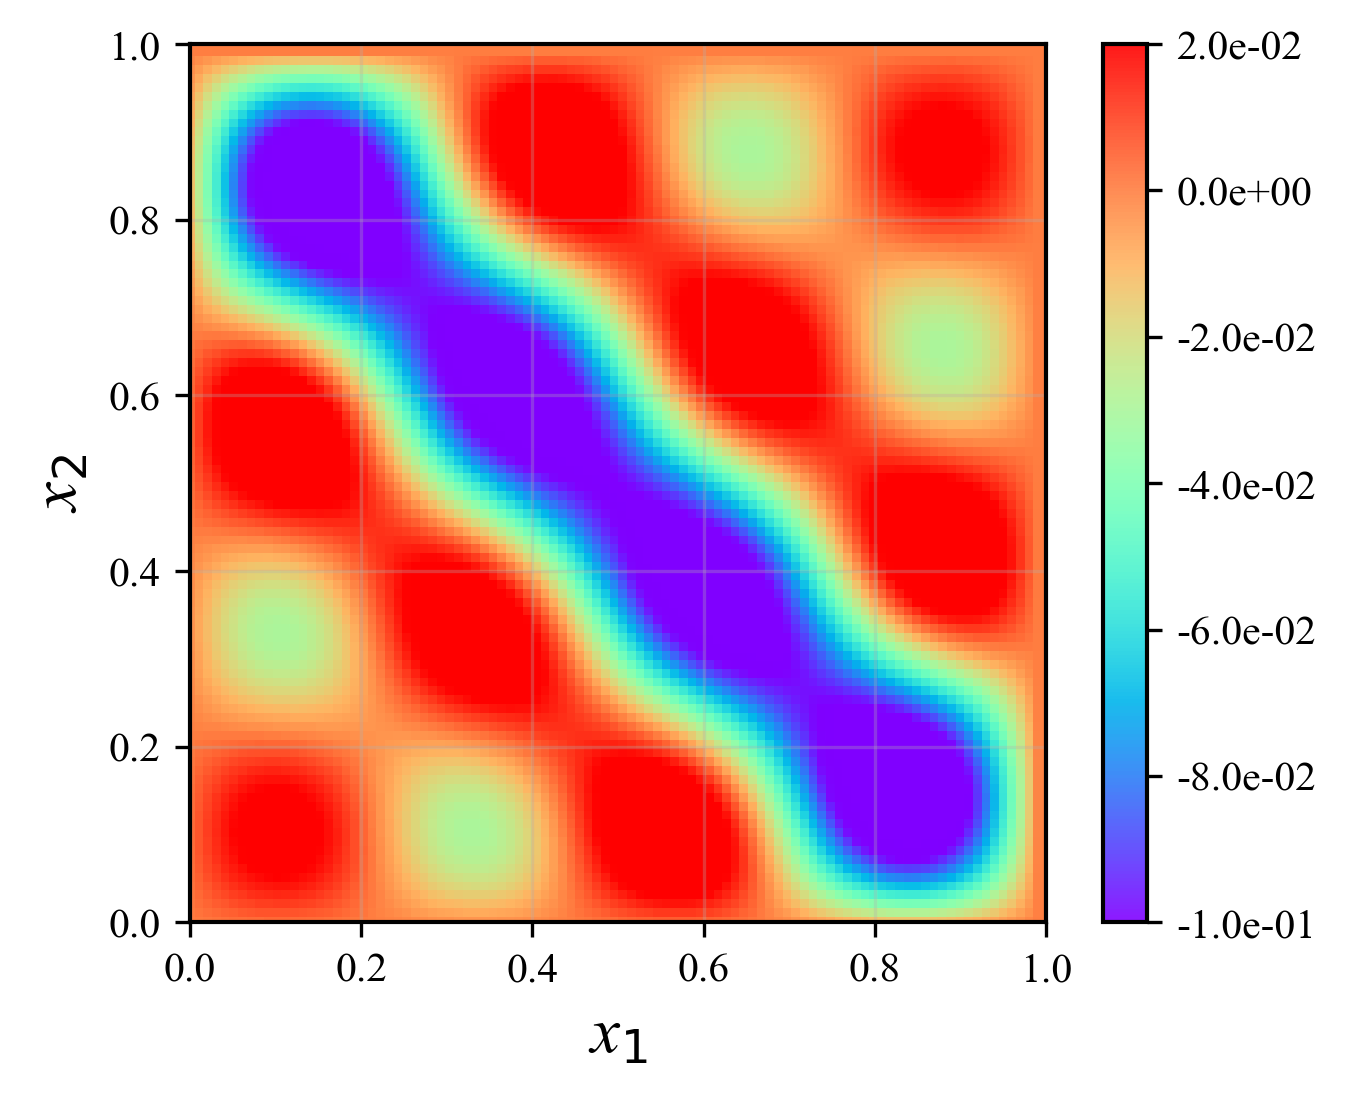

In [5]:
# 绘制sin(pi x)cos(pi y)图像
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 定义 x 和 y 的范围
x = np.linspace(0, 1, 100)  # x 的范围
y = np.linspace(0, 1, 100)  # y 的范围

# 创建网格
X, Y = np.meshgrid(x, y)

k = np.arange(1, 5)  # k 的范围
print(k)
# 计算 z = sin(pi x) * cos(pi y)
# Z = sum([1/2/k/np.pi * (-1)**(k + 1) * np.sin(k*np.pi*X) * np.sin(k*np.pi*Y) for k in k])
Z = -sum([1/2/ (np.pi**2) * (-1)**(k + 1) * np.sin(k*np.pi*X) * np.sin(k*np.pi*Y)  for k in k] )
print(min(Z.flatten()))

# 绘制二维等高线图
fig, ax = plt.subplots(figsize=(3.85, 3.5)) 
cf = ax.scatter(X, Y, c=Z, alpha=1 - 0.1, edgecolors='none', cmap='rainbow',marker='s', vmin=-0.1, vmax = 0.02)
plt.margins(0)  #图像是不需要坐标轴处的空白的
plt.tight_layout()  
# plt.grid()
# plt.colorbar(cf, fraction=0.046, pad=0.04)


# 添加 colorbar
cbar = plt.colorbar(cf, fraction=0.046, pad=0.06)
    # 设置 colorbar 的刻度格式为科学计数法
cbar.ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1e'))
plt.xlabel("x"'$_1$', style='italic')
plt.ylabel("x"'$_2$', style='italic')
plt.grid(alpha=0.3)
plt.savefig(f'./Paper_figures/Poisson_exact.png', dpi=300, bbox_inches='tight')
plt.show()


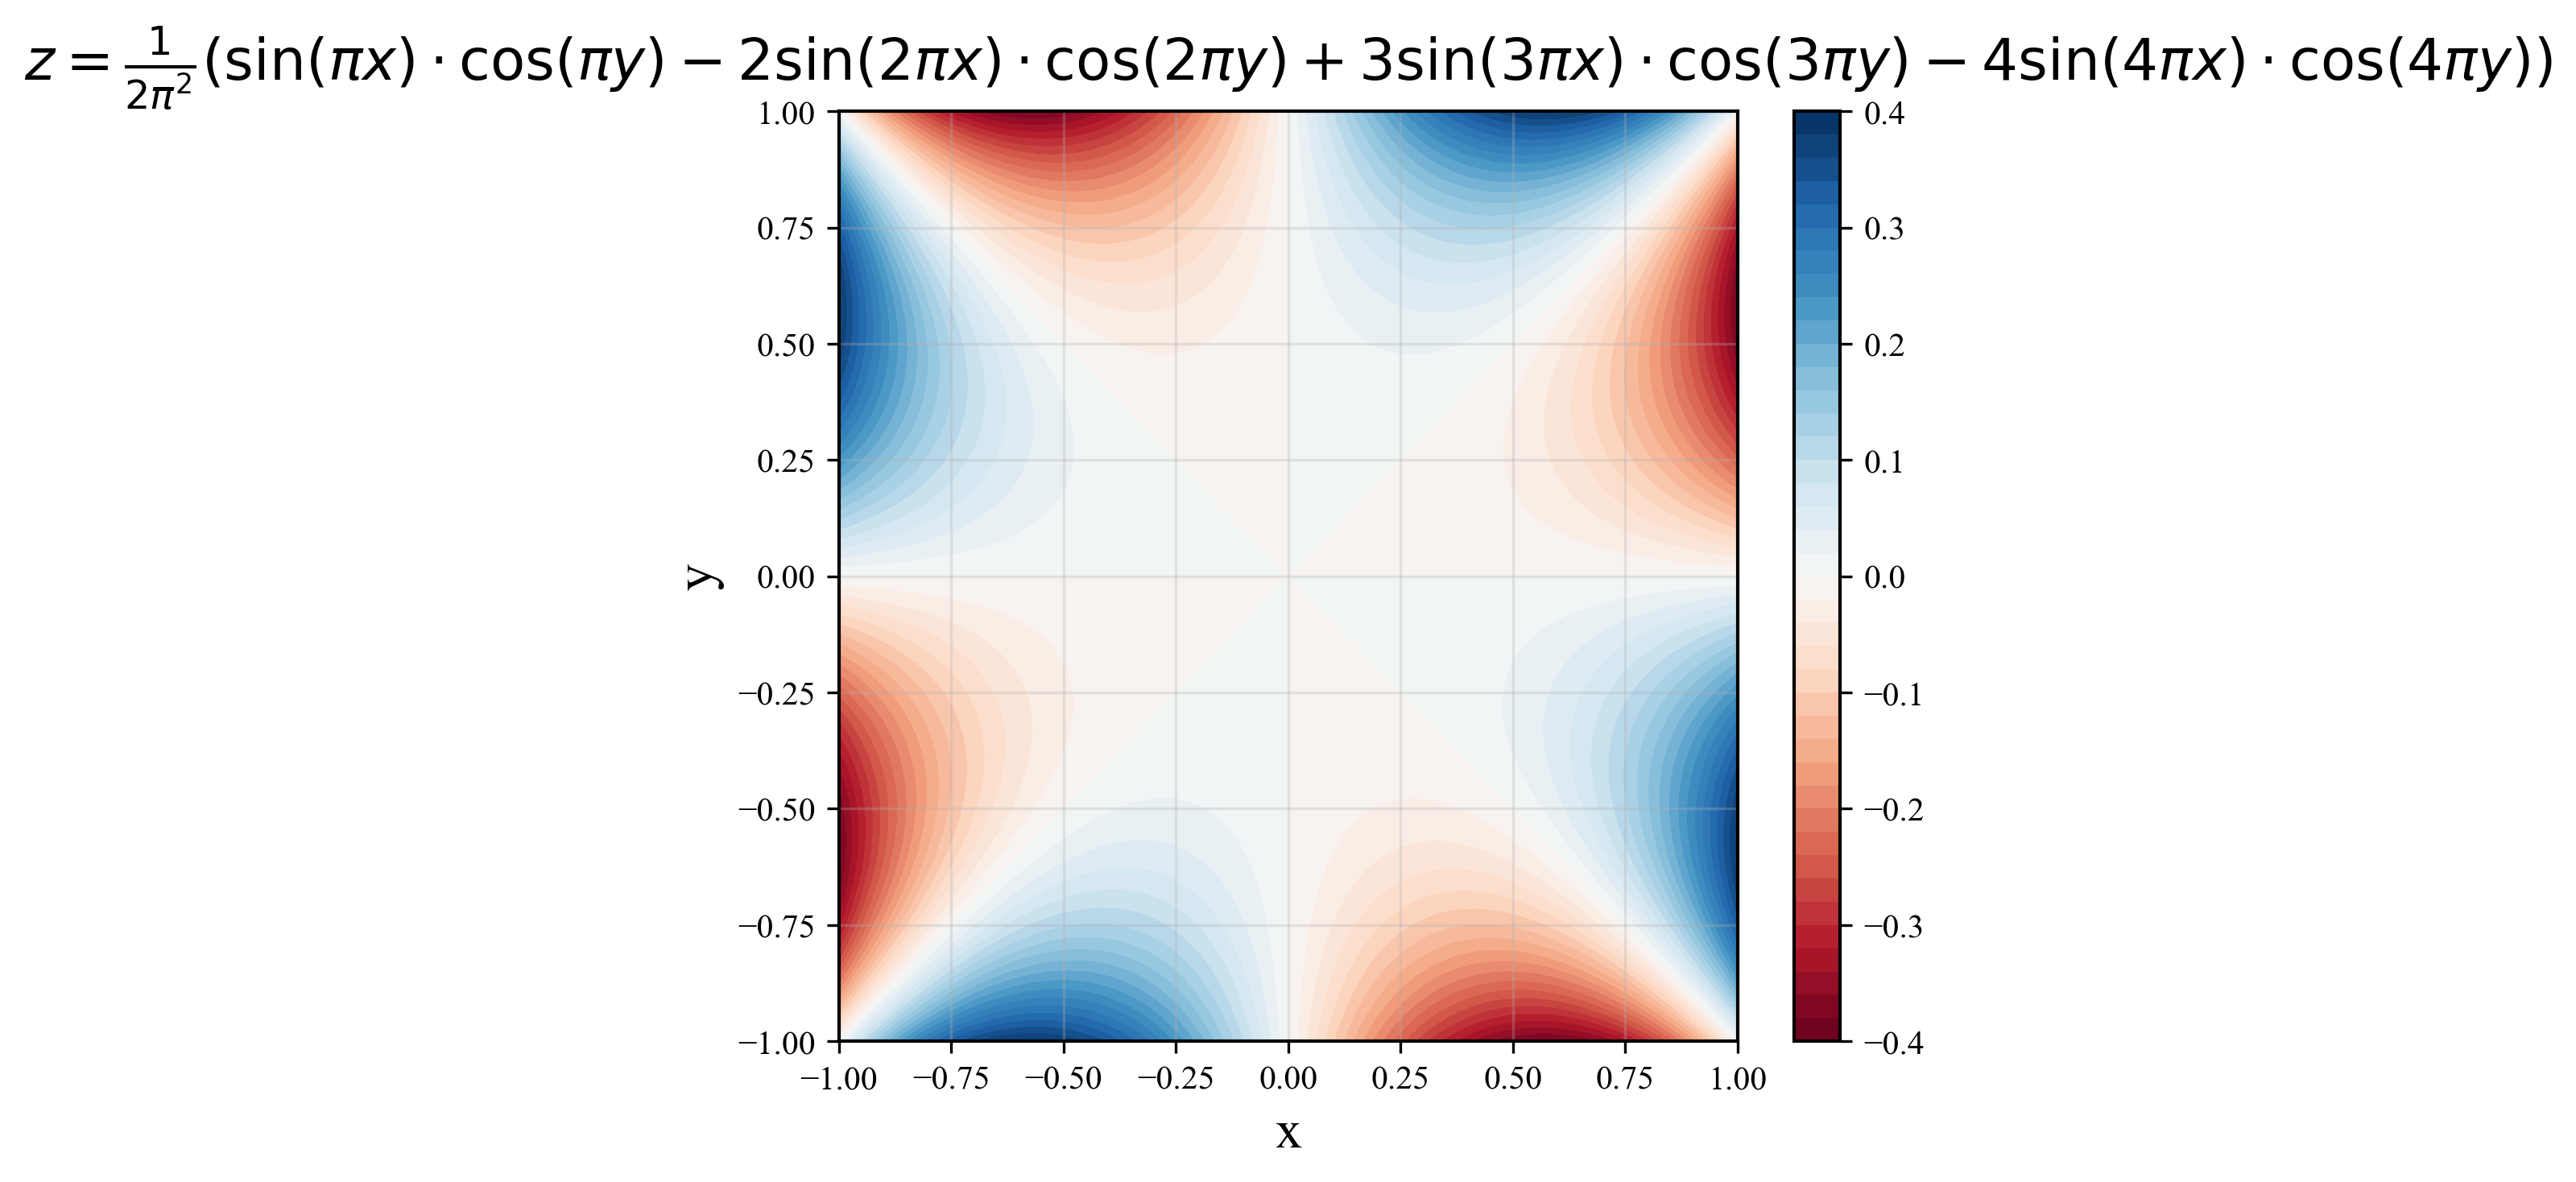

In [9]:
# 绘制0.5 / (2*torch.pi**2) * ((torch.sin(np.pi * (self.x)) * torch.cos(np.pi * (self.y)))- (2 * torch.sin(2 * np.pi * (self.x)) * torch.cos(2 * np.pi * (self.y))) + (3 * torch.sin(3 * np.pi * (self.x)) * torch.cos(3 * np.pi * (self.y))) - (4 * torch.sin(4 * np.pi * (self.x)) * torch.cos(4 * np.pi * (self.y))))图像

import numpy as np
import matplotlib.pyplot as plt
import torch

# 定义 x 和 y 的范围
x = np.linspace(-1, 1, 100)  # x 的范围
y = np.linspace(-1, 1, 100)  # y 的范围

# 创建网格
X, Y = np.meshgrid(x, y)

# # 计算 z = 0.5 / (2*torch.pi**2) * ((torch.sin(np.pi * (self.x)) * torch.cos(np.pi * (self.y)))- (2 * torch.sin(2 * np.pi * (self.x)) * torch.cos(2 * np.pi * (self.y))) + (3 * torch.sin(3 * np.pi * (self.x)) * torch.cos(3 * np.pi * (self.y))) - (4 * torch.sin(4 * np.pi * (self.x)) * torch.cos(4 * np.pi * (self.y))))
# Z = 0.5 / (2 * np.pi**2) * ((np.sin(np.pi * X) * np.cos(np.pi * Y)) -
#         (2 * np.sin(2 * np.pi * X) * np.cos(2 * np.pi * Y)) +
#         (3 * np.sin(3 * np.pi * X) * np.cos(3 * np.pi * Y)) -
#         (4 * np.sin(4 * np.pi * X) * np.cos(4 * np.pi * Y)))
Z = X*Y**3 - X**3 * Y

# 绘制二维等高线图
plt.figure(figsize=(6, 5))
contour = plt.contourf(X, Y, Z, levels=50, cmap='RdBu')  # 填充等高线
plt.colorbar(contour)  # 添加颜色条
plt.title(r"$z = \frac{1}{2\pi^2} \left( \sin(\pi x) \cdot \cos(\pi y) - 2 \sin(2\pi x) \cdot \cos(2\pi y) + 3 \sin(3\pi x) \cdot \cos(3\pi y) - 4 \sin(4\pi x) \cdot \cos(4\pi y) \right)$")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(alpha=0.3)

plt.show()